## Schelling's Model via Network Rewiring (Agent Satisfaction-Based)
This notebook implements the "Evolving Social Networks" model based on Henry, Prałat, and Zhang (2011), with a key modification: agents rewire based on their **personal satisfaction** rather than random edge breaking.

### The Mechanism:
1. **Nodes:** $N$ agents assigned to one of two groups (e.g., 0 or 1).
2. **Initial State:** A random graph (Erdős-Rényi) with a fixed number of edges.
3. **Dynamics (Satisfaction-Based):**
    - Each node measures its **satisfaction**: the fraction of same-type neighbors.
    - At each step, if a node's satisfaction is below threshold $p_{aversion}$, it is **unsatisfied**.
    - **All unsatisfied nodes simultaneously** remove one cross-group connection and create a new edge to a **random node** (any type).
    - The process continues until **all nodes are satisfied** (segregation complete).
4. **Goal:** Observe how the network transitions from a random state to a highly segregated (homophilous) state driven by agent preferences.

## 1. Environment Setup
We use `networkx` for graph manipulation and `matplotlib` for visualizing the emergence of homophily.

In [36]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import os
# Model Parameters
N = 1000            # Total number of nodes (agents)
AVG_DEGREE = [4, 10, 40]     # Average connections per node
P_AVERSION = [0.5, 0.75, 0.95]   # Satisfaction threshold: min fraction of same-type neighbors required for a node to be satisfied
RATIO = [0.5, 0.3]  # Balance between Group 0 and Group 1 (0.5 = 50/50)
ITERATIONS = 5000  # Total steps in the simulation
ERDOS_RENYI = [True, False]  # Set to False to use Barabási-Albert model instead of Erdős-Rényi

EVOLUTION_PLOTS = False  # Set to True to enable plotting during evolution

parent_logs = f"experiment_results_{N}_{AVG_DEGREE}_{P_AVERSION}_{RATIO}_{'ER' if ERDOS_RENYI else 'BA'}_{ITERATIONS}"
os.makedirs(parent_logs, exist_ok=True)
os.makedirs(f"{parent_logs}/evolutionary_graph", exist_ok=True)

## 2. Initializing the Random Graph
The simulation starts with an **Erdős-Rényi** random graph $G(n, p_{edge})$. We then randomly assign each node a "type" (0 or 1) based on the defined ratio. At this stage, the network should show very low homophily.

In [37]:
def initialize_network(n, k, ratio, erdos_renyi=True):
    p_edge = k / (n - 1)
    if erdos_renyi:
         G = nx.fast_gnp_random_graph(n, p_edge)
    else:   
        m = k//2  # Number of edges to attach from a new node to existing nodes (1 <= m < n)
        G = nx.barabasi_albert_graph(n, m)
    
    nodes = list(G.nodes())
    random.shuffle(nodes)
    split = int(n * ratio)
    
    for i, node in enumerate(nodes):
        G.nodes[node]['type'] = 0 if i < split else 1
        
    return G


## 3. Measuring Homophily
To quantify segregation, we calculate the **Homophily Index**, defined as the fraction of internal edges (same-type connections) over the total number of edges in the network.
$$H = \frac{E_{internal}}{E_{total}}$$
A value of 0.5 indicates a perfectly mixed random state, while 1.0 indicates total segregation.

In [38]:
def get_homophily(G):
    internal = 0
    total = G.number_of_edges()
    if total == 0: return 0
    
    for u, v in G.edges():
        if G.nodes[u]['type'] == G.nodes[v]['type']:
            internal += 1
    return internal / total

def get_satisfaction(G, node):
    """Calculate the fraction of same-type neighbors for a node."""
    neighbors = list(G.neighbors(node))
    if not neighbors:
        return 1.0  # Isolated nodes are considered satisfied
    
    node_type = G.nodes[node]['type']
    same_type_count = sum(1 for n in neighbors if G.nodes[n]['type'] == node_type)
    return same_type_count / len(neighbors)

def get_unsatisfied_nodes(G, threshold):
    """Return list of nodes whose satisfaction is below the threshold."""
    return [n for n in G.nodes() if get_satisfaction(G, n) < threshold]


## 4. The Rewiring Process (Agent Satisfaction-Based)
At every time step, **all unsatisfied nodes simultaneously execute**:
1. Identify their **cross-edges** (connections to opposite-type nodes).
2. Remove one cross-edge randomly.
3. Create a new edge to a **random node** (any node, any type) that is not currently a neighbor.

This synchronous mechanism mimics the original Schelling model: when agents are dissatisfied, they move to random empty spaces without control over neighbor composition. The process repeats until **all nodes are satisfied**.

In [39]:
def simulate_step(G, satisfaction_threshold):
    """
    Perform one step of the Schelling model based on agent satisfaction.
    Each unsatisfied node removes one cross-edge and rewires to a random
    non-neighbor, regardless of the new node's type.
    Returns False if all nodes are satisfied (steady state reached).
    """
    unsatisfied = get_unsatisfied_nodes(G, satisfaction_threshold)
    
    if not unsatisfied:
        return False  # All nodes are satisfied - steady state reached
    
    for u in unsatisfied:
        u_type = G.nodes[u]['type']

        # Find cross-edges (connections to opposite-type nodes)
        cross_neighbors = [v for v in G.neighbors(u) if G.nodes[v]['type'] != u_type]
    
        if not cross_neighbors:
            # Node is unsatisfied but has no cross-edges (shouldn't normally happen)
            continue
    
        # Remove one cross-edge randomly
        v = random.choice(cross_neighbors)
        G.remove_edge(u, v)
    
        # Find potential nodes to connect with (not already neighbors)
        potential = [n for n in G.nodes() if n != u and not G.has_edge(u, n)]
    
        if potential:
            new_neighbor = random.choice(potential)
            G.add_edge(u, new_neighbor)
            
    return True




## 5. Visualizing Segregation
We plot the evolution of the Homophily Index over time and render the final graph layout. In the graph, nodes of the same color should cluster together, forming distinct communities.

In [40]:
def plot_final_results(
    G,
    history,
    param_string,
    exp_dir,
    step,
    exp_name,
    avg_degree,
    ratio,
    p_aversion,
    model_label,
    N,
    plot_history=False
):

    if plot_history:
        fig, ax = plt.subplots(1, 2, figsize=(16, 6))

        # Plot evolución homofilia
        ax[0].plot(history, color='royalblue', lw=2)
        ax[0].set_title(f"Homophily Index Evolution - Final value: {history[-1]:.4f}")
        ax[0].set_xlabel("Iterations")
        ax[0].set_ylabel("Index")
        ax[0].grid(alpha=0.3)

        network_ax = ax[1]

    else:
        fig, network_ax = plt.subplots(1, 1, figsize=(8, 6))

    # Plot red final
    pos = nx.spring_layout(G, k=0.15)
    colors = ['#E63946' if G.nodes[n]['type'] == 0 else '#1D3557' for n in G.nodes()]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=30,
        node_color=colors,
        ax=network_ax
    )

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.09,
        ax=network_ax,
        edge_color='black',
        width=0.4
    )

    network_ax.set_title(
        f"Final Segregated Network Structure"
    )

    plt.figtext(
        0.5,
        0.01,
        param_string,
        wrap=True,
        horizontalalignment='center',
        fontsize=10,
        style='italic'
    )

    plt.subplots_adjust(bottom=0.15)

    os.makedirs(exp_dir, exist_ok=True)

    plt.savefig(
        f'{exp_dir}/{exp_name}_final_network_N{N}_avgdegree{avg_degree}_tau{p_aversion}_ratio{ratio}_{model_label}.png'
    )

    plt.show()


## 6. Ensemble Analysis
Because the model is stochastic, a single run is not statistically significant. To produce robust results, we run the simulation multiple times for the same parameters and calculate the **mean** and **standard deviation**.

In [41]:
def run_ensemble(repeats=20, avg_degree=AVG_DEGREE[0], ratio=RATIO[0], p_aversion=P_AVERSION[0], erdos_renyi=ERDOS_RENYI[0]):
    """Run multiple ensemble simulations with the same parameters."""
    os.makedirs(parent_logs, exist_ok=True)
    all_runs = []
    all_initial_homophily = []
    all_initial_unsatisfied = []
    all_full_segregation_steps = []
    all_final_homophily = []
    for run_num in range(repeats):
        temp_G = initialize_network(N, avg_degree, ratio, erdos_renyi)

        initial_homophily = get_homophily(temp_G)
        initial_unsatisfied = len(get_unsatisfied_nodes(temp_G, p_aversion))
        run_data = []
        full_segregation_step=-1
        for i in range(ITERATIONS):
            active = simulate_step(temp_G, p_aversion)
            run_data.append(get_homophily(temp_G))
            if not active:  # Early stopping if all nodes are satisfied
                full_segregation_step = i
                break
        final_homophily = run_data[-1]
        all_runs.append(run_data)
        all_initial_homophily.append(initial_homophily)
        all_initial_unsatisfied.append(initial_unsatisfied)
        all_full_segregation_steps.append(full_segregation_step)
        all_final_homophily.append(final_homophily)
    return all_runs, np.mean(all_initial_homophily), np.mean(all_initial_unsatisfied), np.mean(all_full_segregation_steps), np.mean(all_final_homophily)


def plot_ensemble_results(param_string, exp_dir, exp_name, avg_degree, ratio, p_aversion, erdos_renyi, N):
    repeats = 20
    ensemble_data, initial_homophily_mean, initial_unsatisfied_mean, full_segregation_steps_mean, final_homophily_mean = run_ensemble(repeats, avg_degree=avg_degree, ratio=ratio, p_aversion=p_aversion, erdos_renyi=erdos_renyi)
    min_length = min(len(run) for run in ensemble_data)
    trimmed_data = np.array([run[:min_length] for run in ensemble_data])
    mean_h = np.mean(trimmed_data, axis=0)
    std_h = np.std(trimmed_data, axis=0)

    x = np.arange(min_length)

    plt.fill_between(x, mean_h - std_h, mean_h + std_h, alpha=0.2, color='royalblue')
    plt.plot(x, mean_h, label="Mean Homophily", color='blue', linewidth=2)

    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel("Homophily Index", fontsize=12)

    plt.title(f"Ensemble Average Over {repeats} Repetitions - Satisfaction-Based Model")

    plt.figtext(0.5, 0.01, param_string, wrap=True, horizontalalignment='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25, top=0.88)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    os.makedirs(exp_dir, exist_ok=True)
    model_label = 'ER' if erdos_renyi else 'BA'
    plt.savefig(f'{exp_dir}/{exp_name}_ensemble_results_N{N}_avgdegree{avg_degree}_tau{p_aversion}_ratio{ratio}_{model_label}.png')
    plt.show()

    return initial_homophily_mean, initial_unsatisfied_mean, full_segregation_steps_mean, final_homophily_mean


Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.5, Ratio=0.5, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5134
Initial unsatisfied nodes: 376
Full segregation achieved at step 8 (all nodes satisfied).
Final Homophily Index: 0.7080


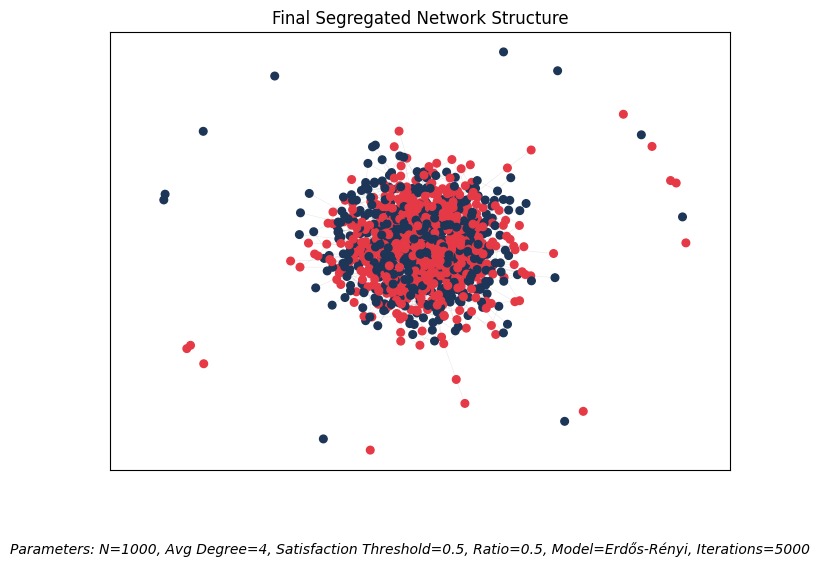

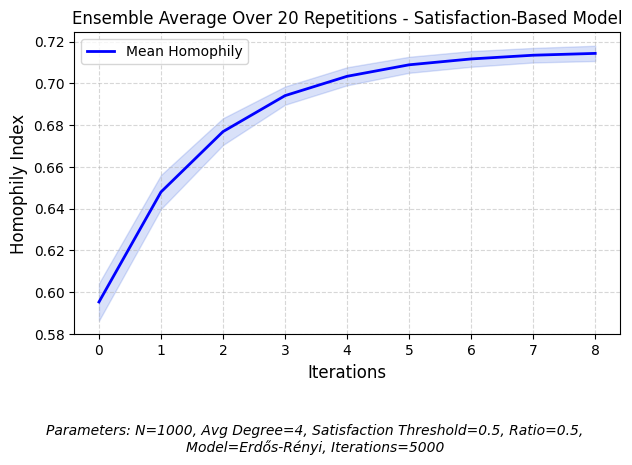

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.5, Ratio=0.5, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.4795
Initial unsatisfied nodes: 383
Full segregation achieved at step 8 (all nodes satisfied).
Final Homophily Index: 0.7024


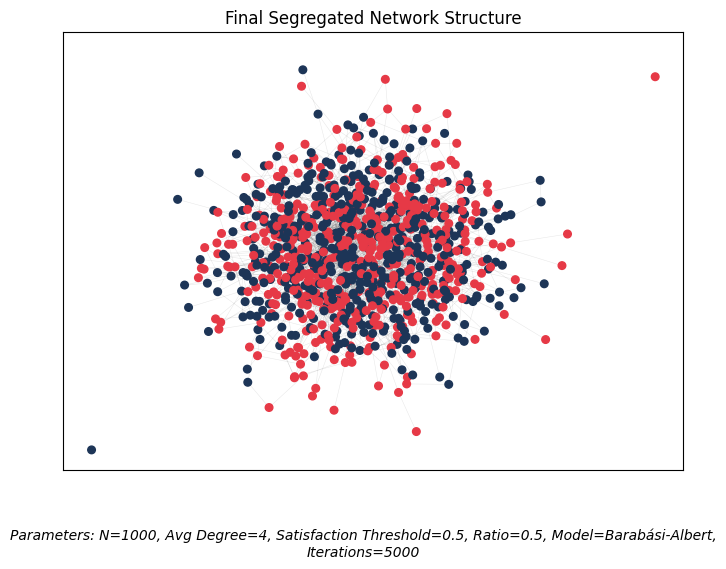

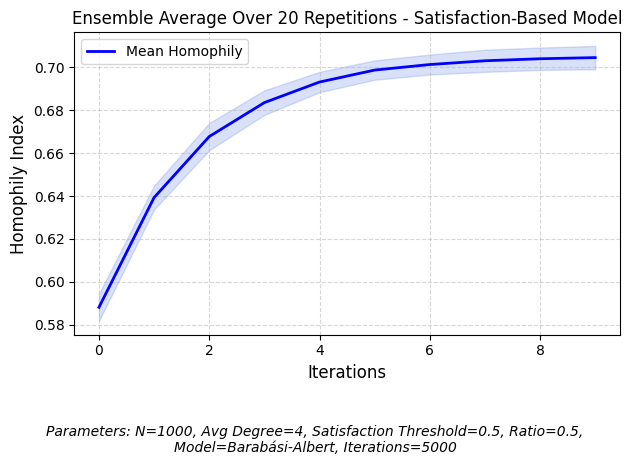

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.75, Ratio=0.5, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5229
Initial unsatisfied nodes: 736
Full segregation achieved at step 16 (all nodes satisfied).
Final Homophily Index: 0.9478


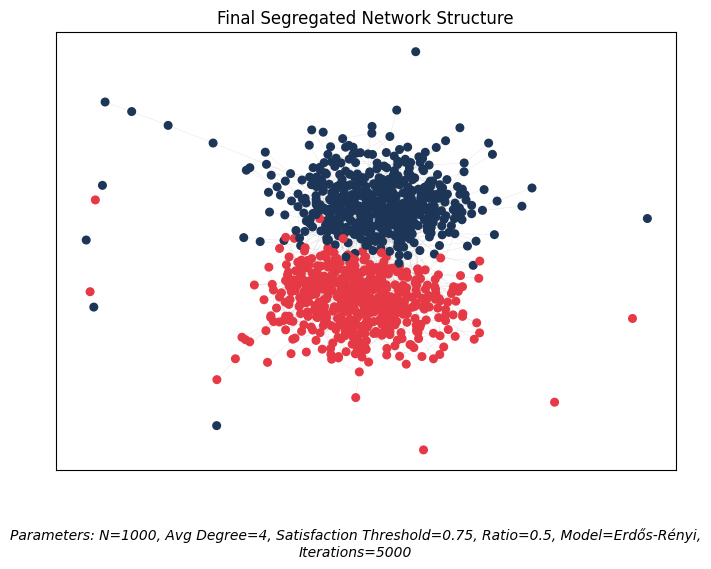

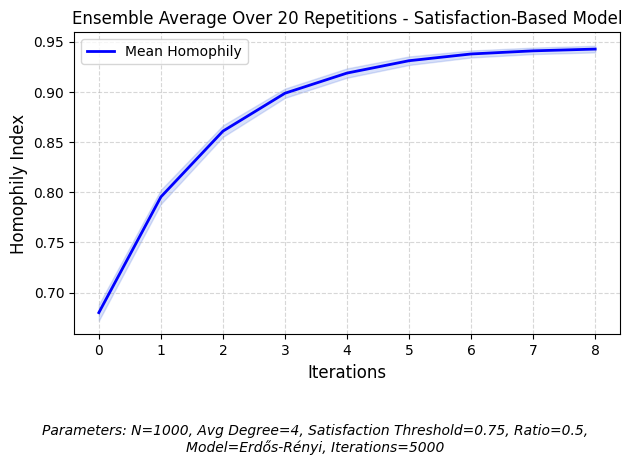

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.75, Ratio=0.5, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5035
Initial unsatisfied nodes: 789
Full segregation achieved at step 14 (all nodes satisfied).
Final Homophily Index: 0.9449


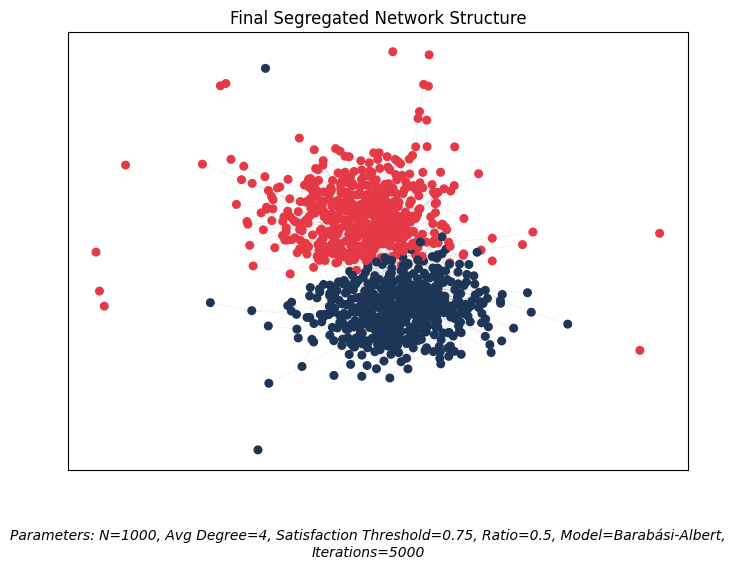

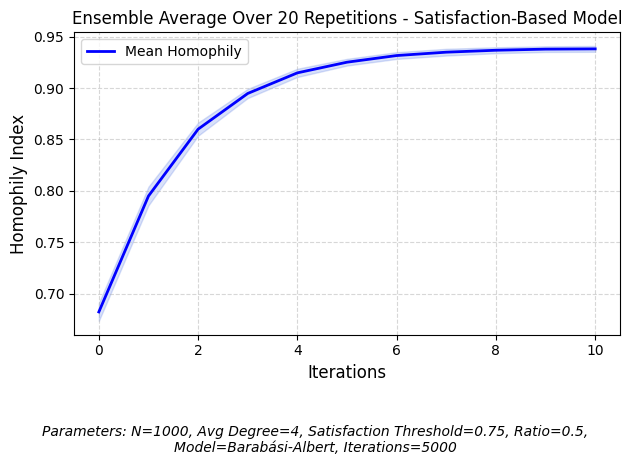

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.95, Ratio=0.5, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.4797
Initial unsatisfied nodes: 868
Full segregation achieved at step 14 (all nodes satisfied).
Final Homophily Index: 1.0000


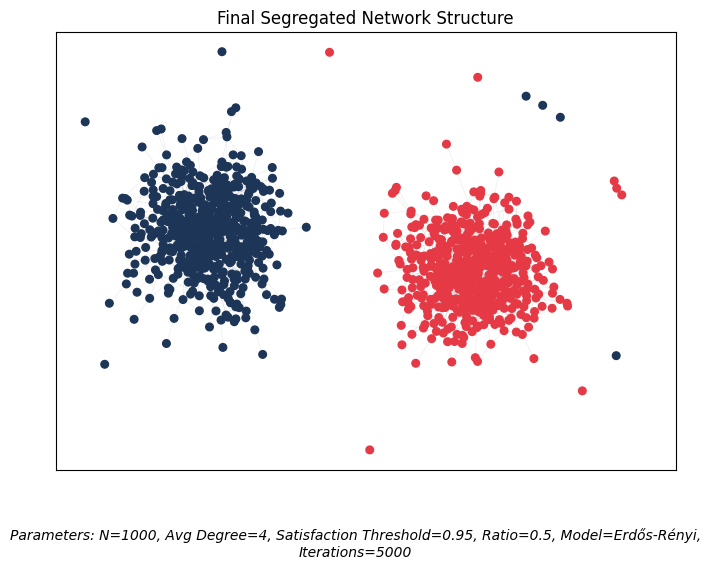

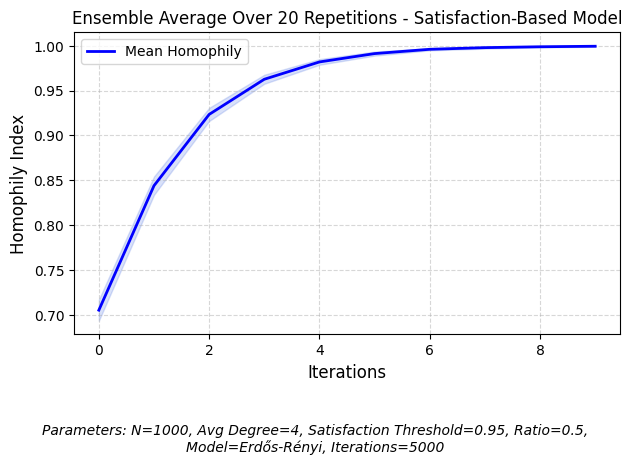

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.95, Ratio=0.5, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.4900
Initial unsatisfied nodes: 833
Full segregation achieved at step 13 (all nodes satisfied).
Final Homophily Index: 1.0000


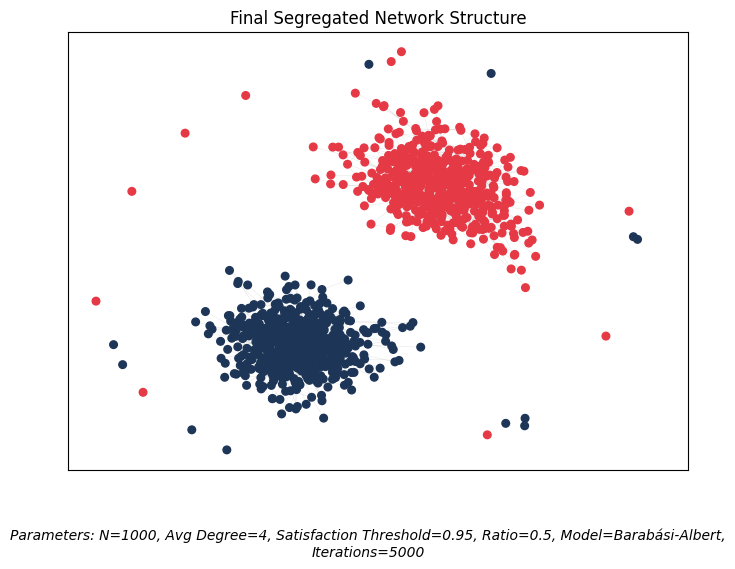

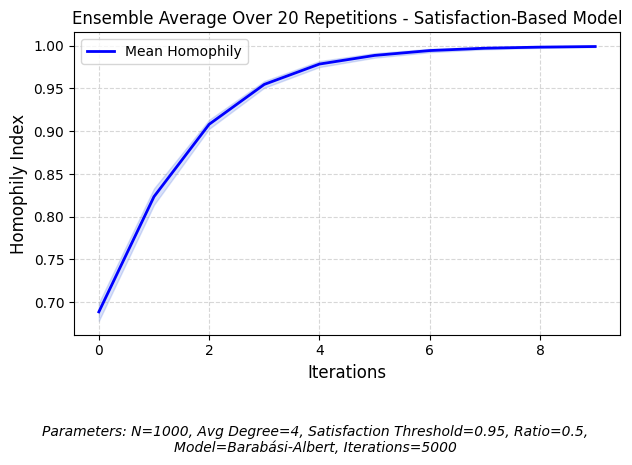

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.5, Ratio=0.5, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5019
Initial unsatisfied nodes: 434
Full segregation achieved at step 17 (all nodes satisfied).
Final Homophily Index: 0.6284


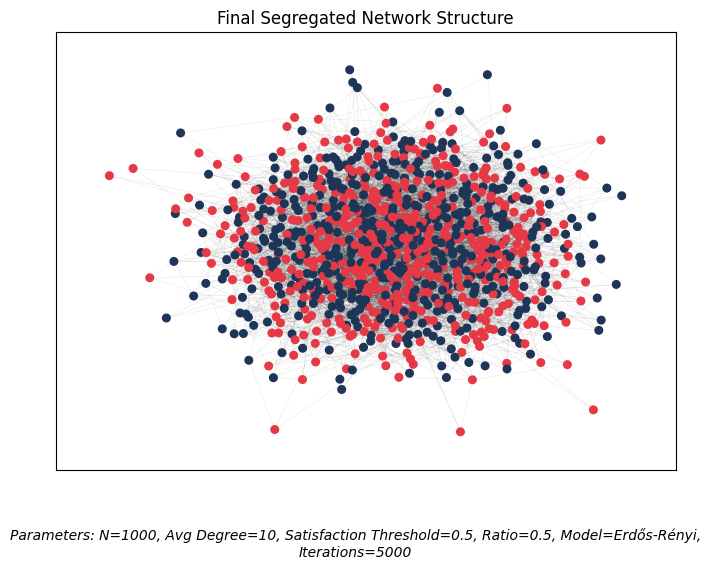

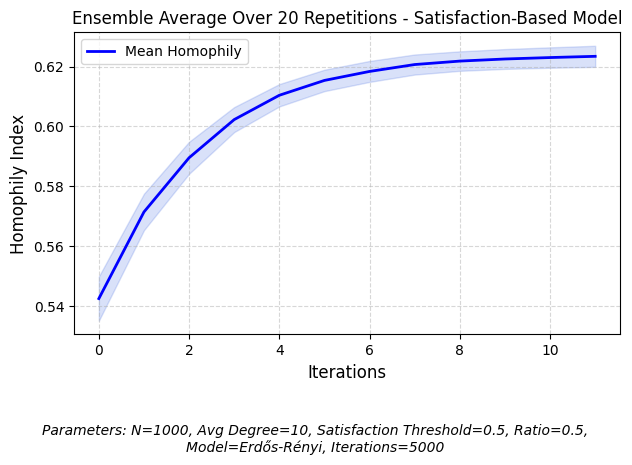

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.5, Ratio=0.5, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.4828
Initial unsatisfied nodes: 499
Full segregation achieved at step 15 (all nodes satisfied).
Final Homophily Index: 0.6211


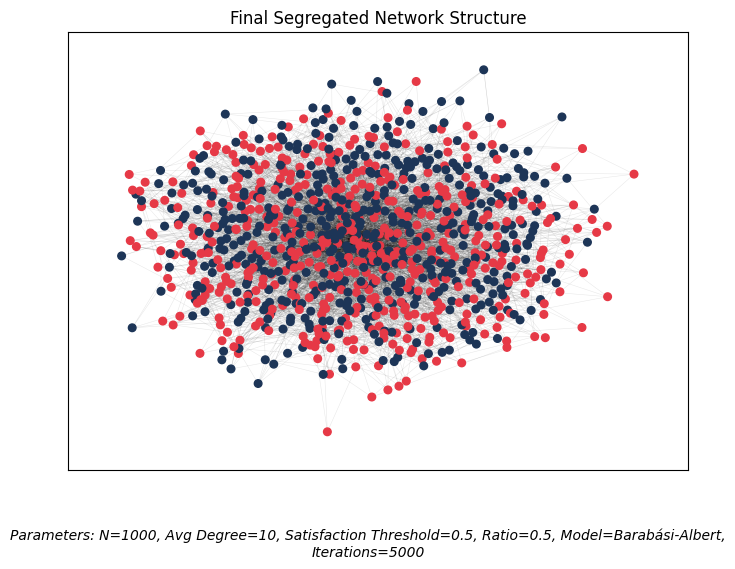

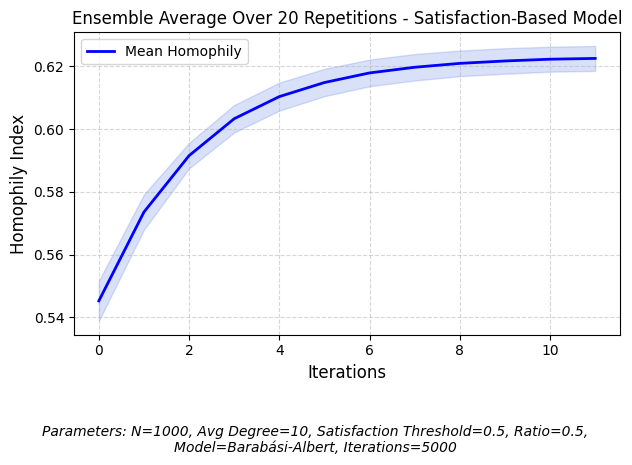

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.75, Ratio=0.5, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.4988
Initial unsatisfied nodes: 931
Full segregation achieved at step 16 (all nodes satisfied).
Final Homophily Index: 0.8662


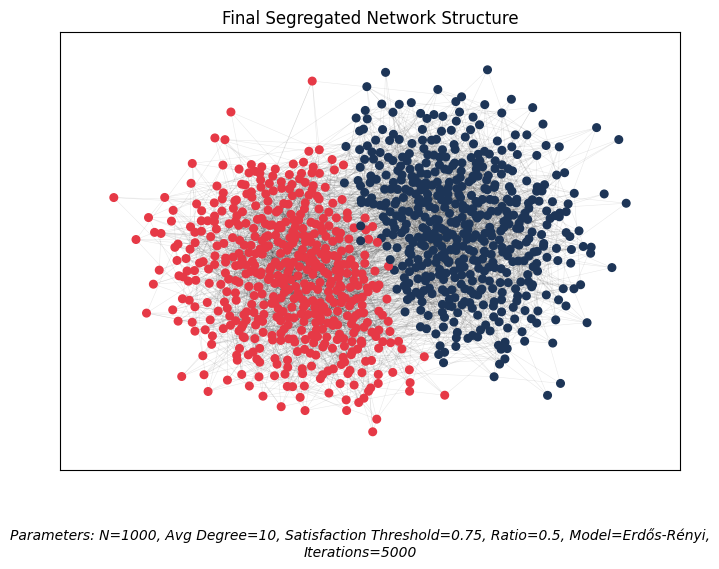

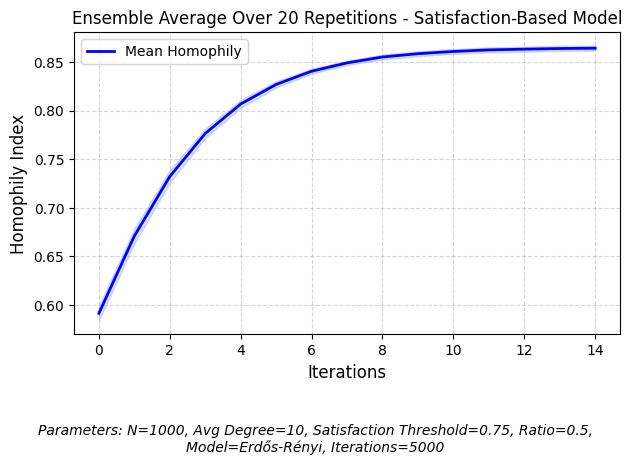

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.75, Ratio=0.5, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5011
Initial unsatisfied nodes: 890
Full segregation achieved at step 17 (all nodes satisfied).
Final Homophily Index: 0.8629


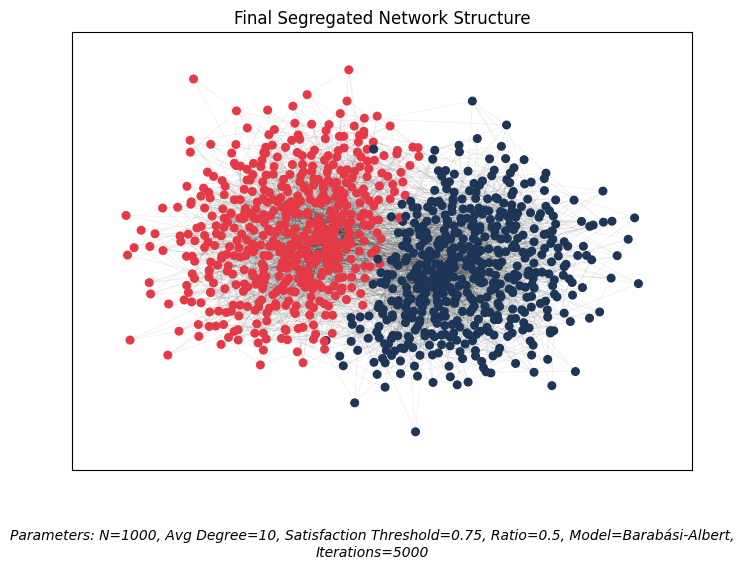

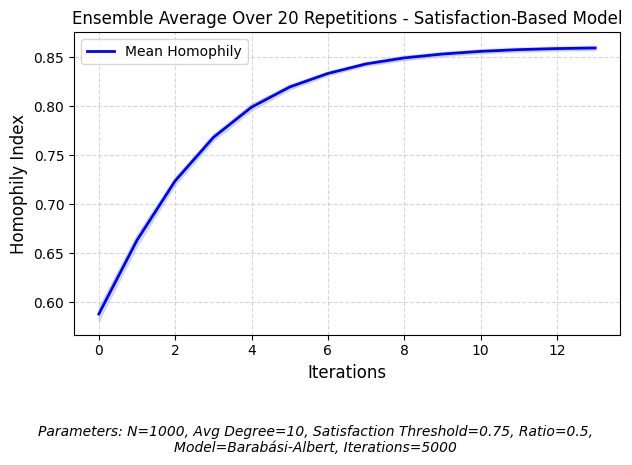

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.95, Ratio=0.5, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.4986
Initial unsatisfied nodes: 992
Full segregation achieved at step 18 (all nodes satisfied).
Final Homophily Index: 1.0000


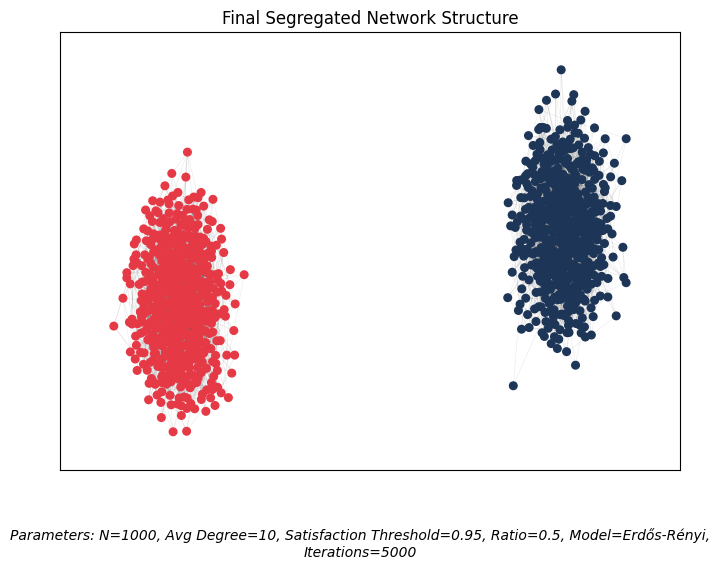

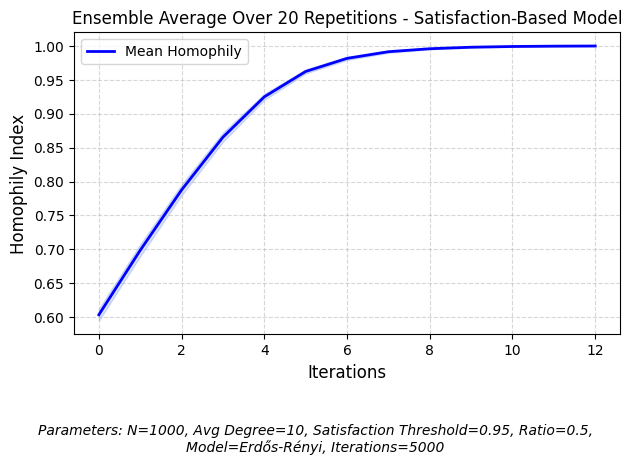

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.95, Ratio=0.5, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.4977
Initial unsatisfied nodes: 992
Full segregation achieved at step 15 (all nodes satisfied).
Final Homophily Index: 0.9988


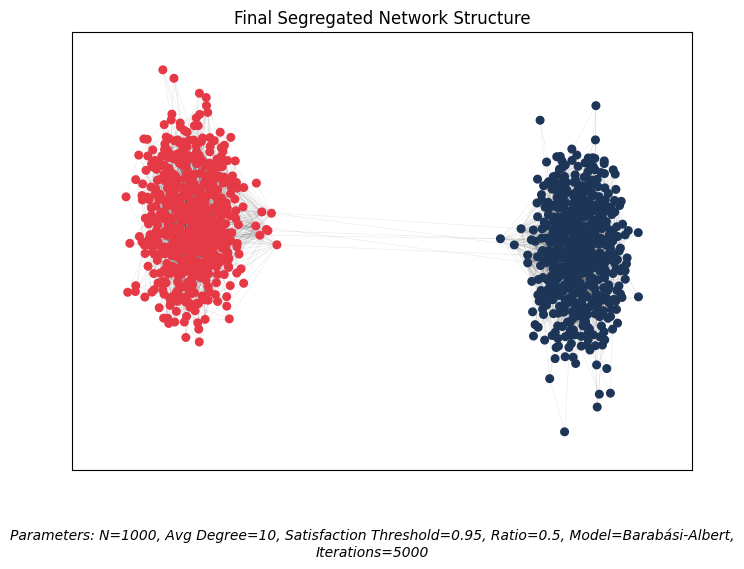

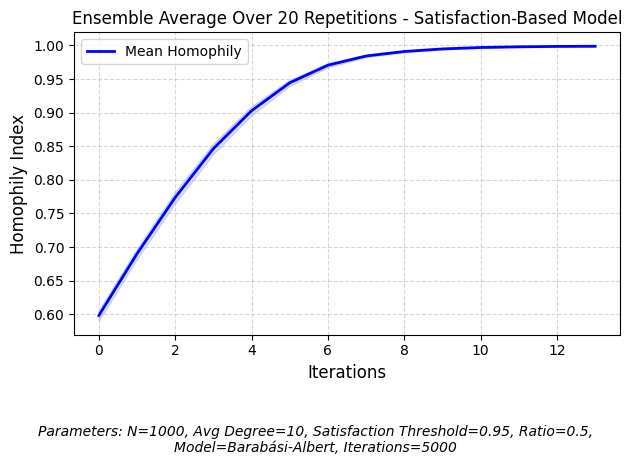

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.5, Ratio=0.5, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.4950
Initial unsatisfied nodes: 487
Full segregation achieved at step 27 (all nodes satisfied).
Final Homophily Index: 0.5553


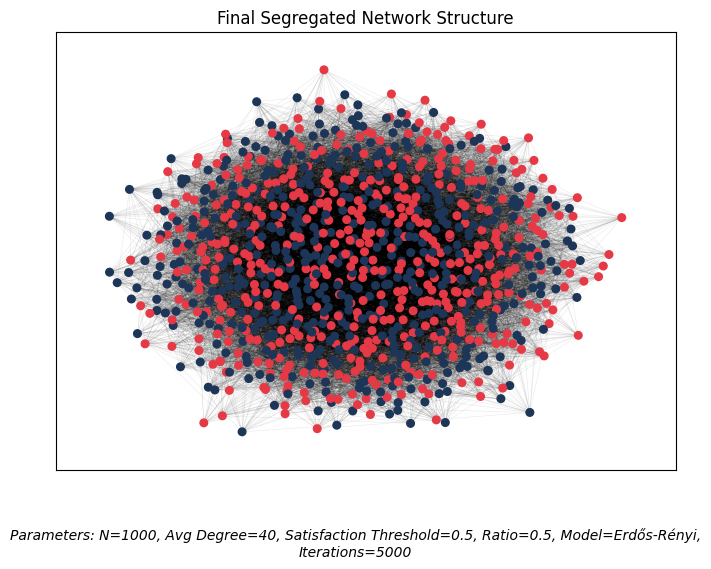

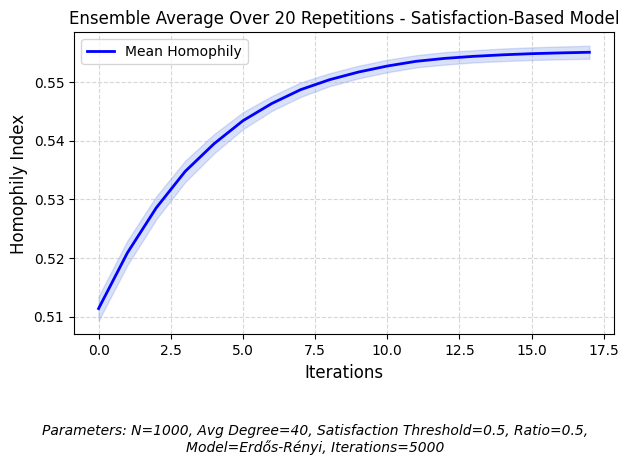

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.5, Ratio=0.5, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5034
Initial unsatisfied nodes: 458
Full segregation achieved at step 23 (all nodes satisfied).
Final Homophily Index: 0.5564


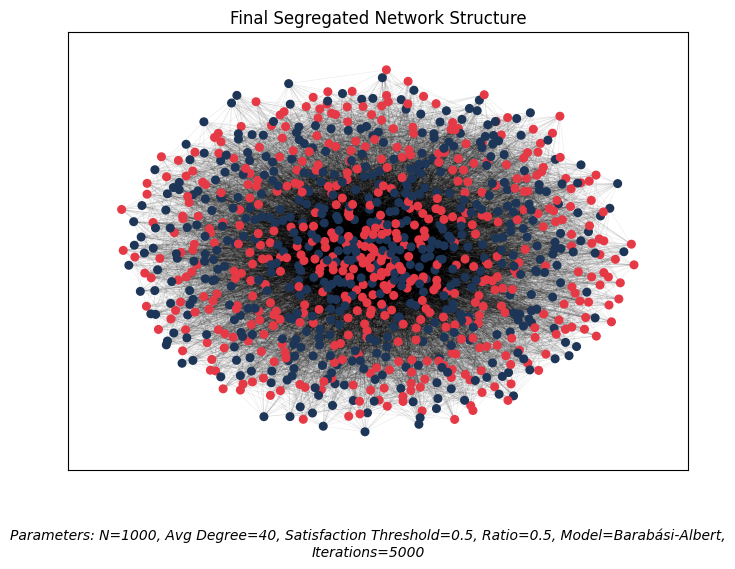

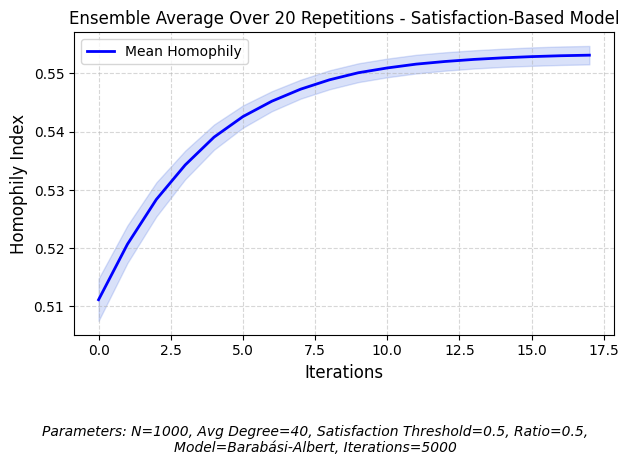

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.75, Ratio=0.5, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5043
Initial unsatisfied nodes: 999
Full segregation achieved at step 30 (all nodes satisfied).
Final Homophily Index: 0.7963


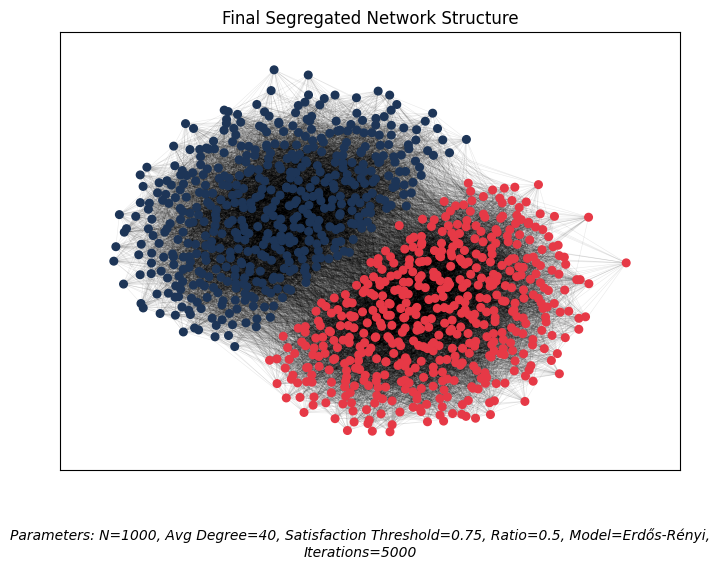

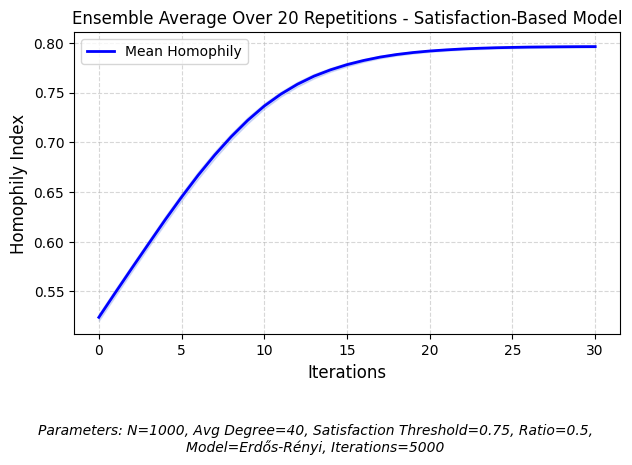

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.75, Ratio=0.5, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5027
Initial unsatisfied nodes: 993
Full segregation achieved at step 49 (all nodes satisfied).
Final Homophily Index: 0.7989


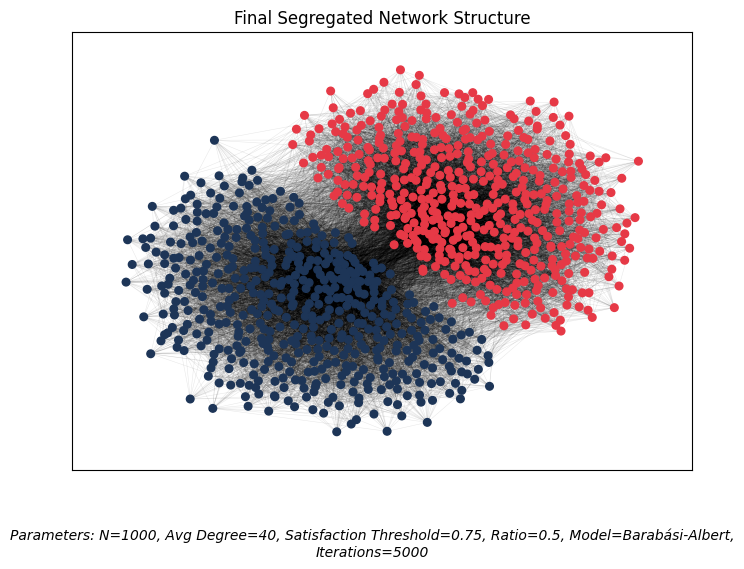

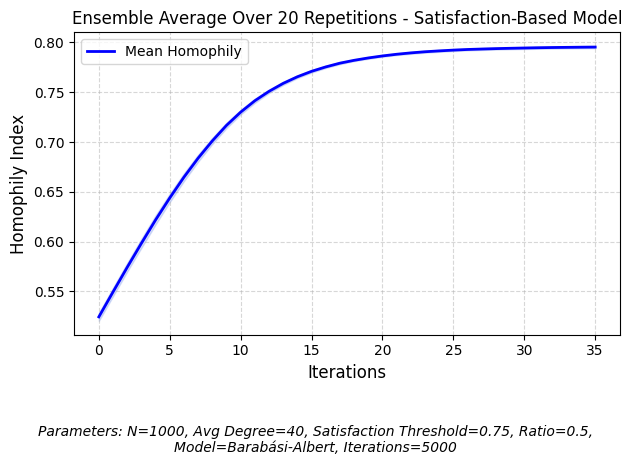

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.95, Ratio=0.5, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5023
Initial unsatisfied nodes: 1000
Full segregation achieved at step 36 (all nodes satisfied).
Final Homophily Index: 0.9821


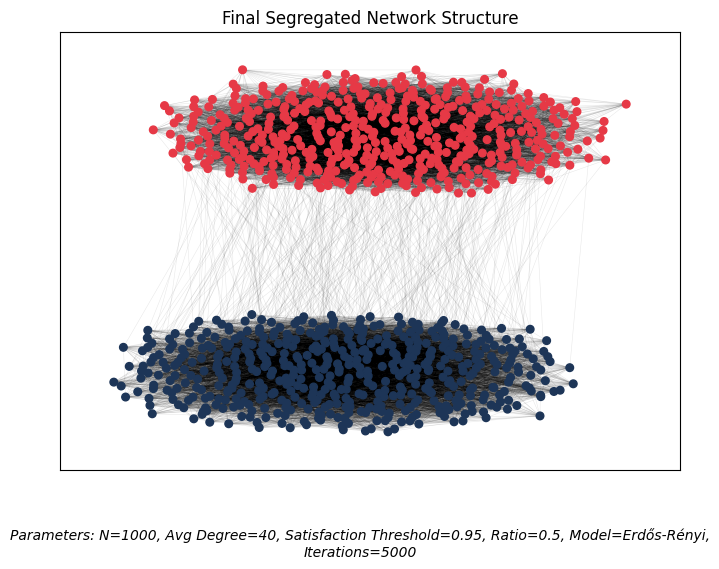

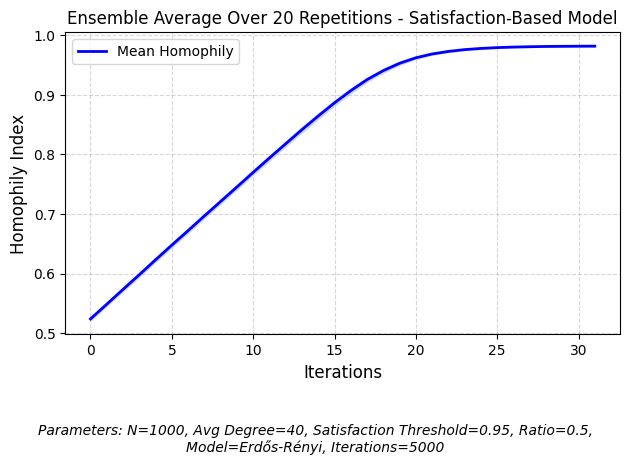

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.95, Ratio=0.5, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5021
Initial unsatisfied nodes: 1000
Full segregation achieved at step 36 (all nodes satisfied).
Final Homophily Index: 0.9818


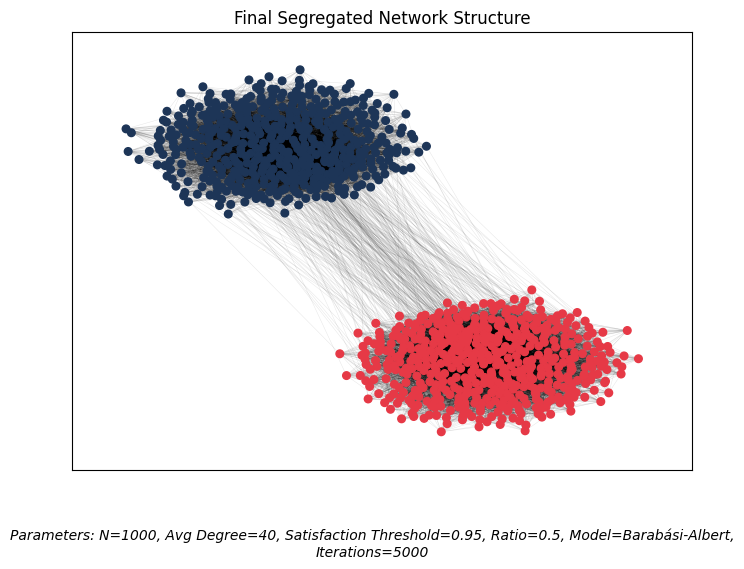

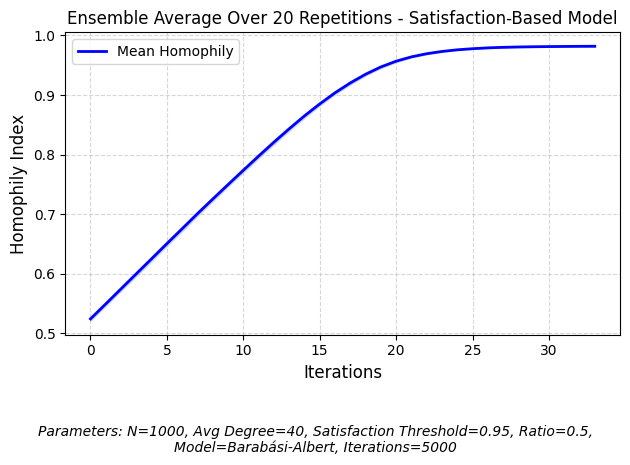

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.5, Ratio=0.3, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5794
Initial unsatisfied nodes: 308
Full segregation achieved at step 18 (all nodes satisfied).
Final Homophily Index: 0.7674


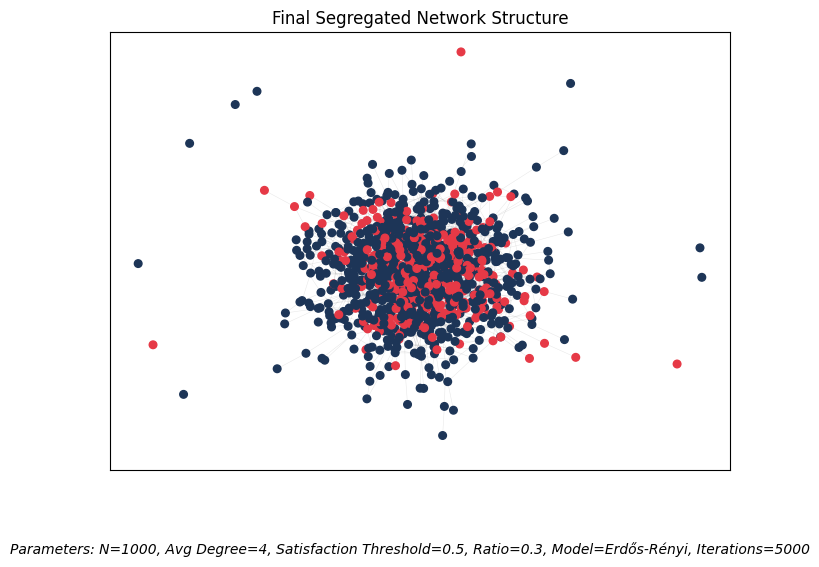

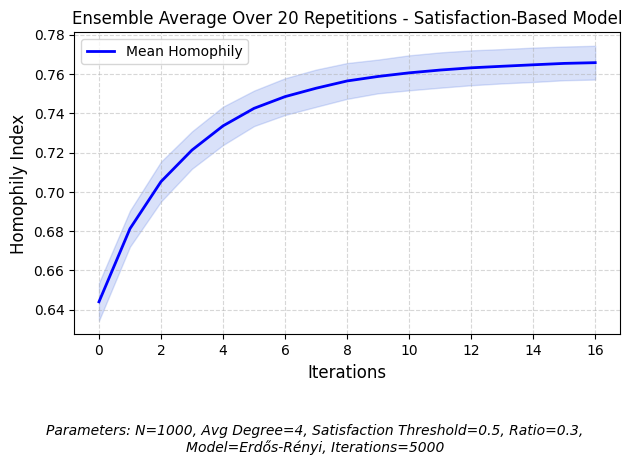

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.5, Ratio=0.3, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5832
Initial unsatisfied nodes: 250
Full segregation achieved at step 34 (all nodes satisfied).
Final Homophily Index: 0.7615


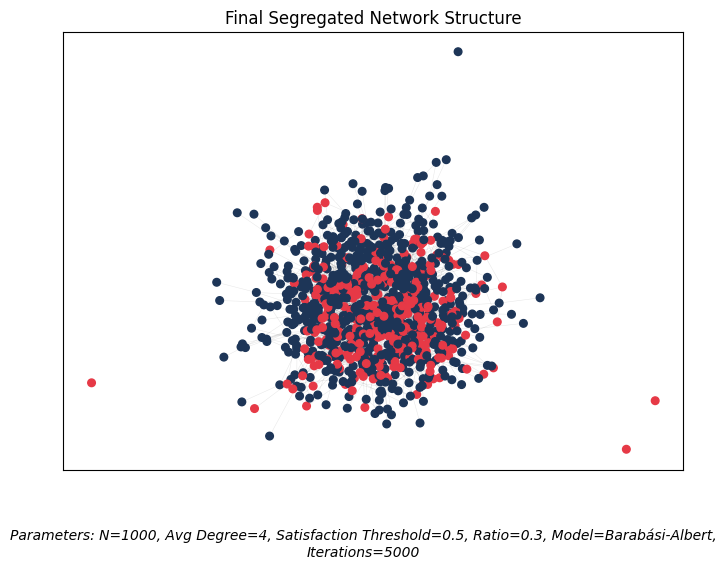

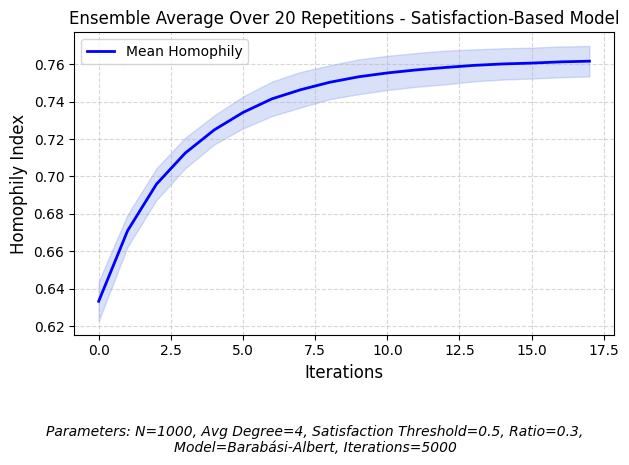

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.75, Ratio=0.3, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5752
Initial unsatisfied nodes: 642
Full segregation achieved at step 19 (all nodes satisfied).
Final Homophily Index: 0.9595


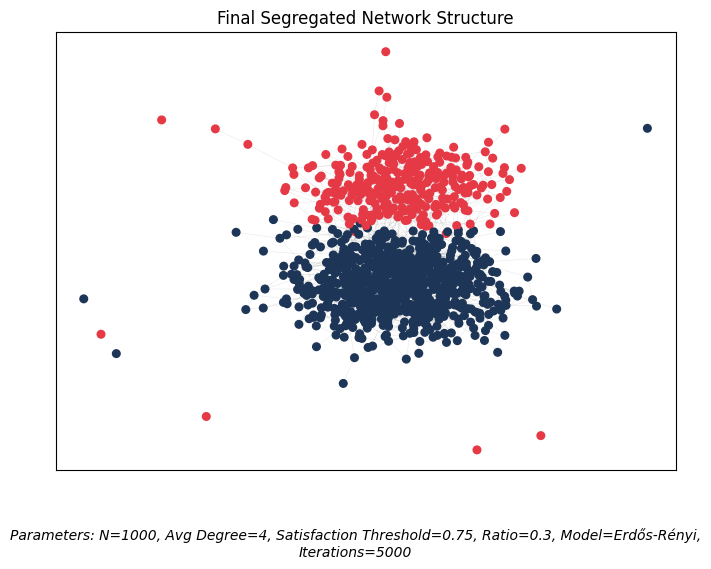

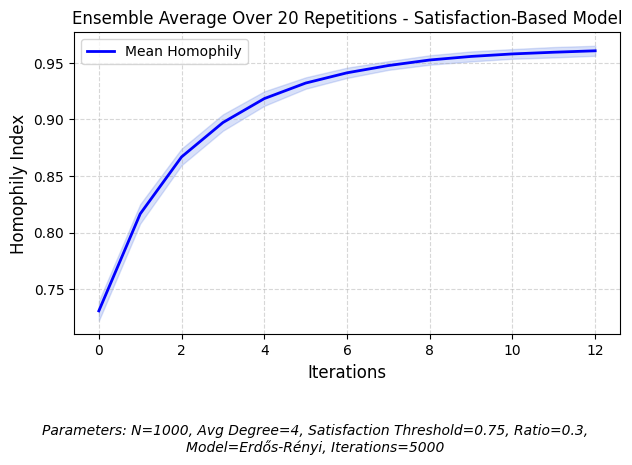

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.75, Ratio=0.3, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5566
Initial unsatisfied nodes: 682
Full segregation achieved at step 20 (all nodes satisfied).
Final Homophily Index: 0.9594


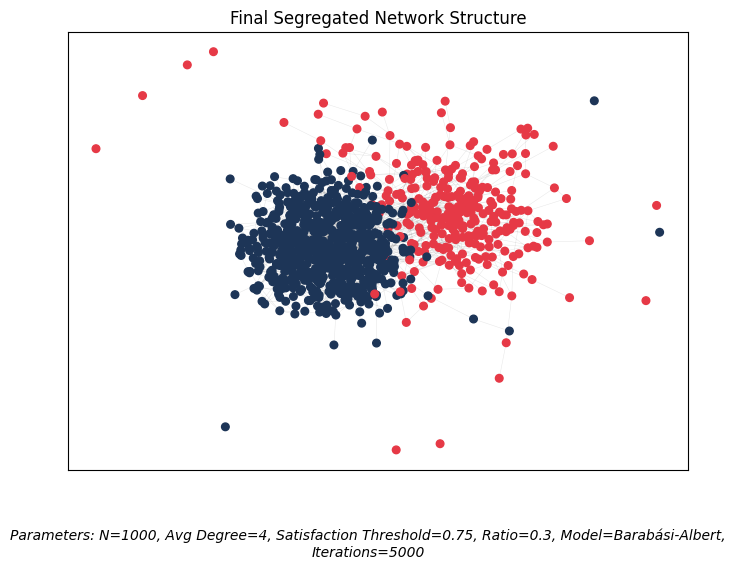

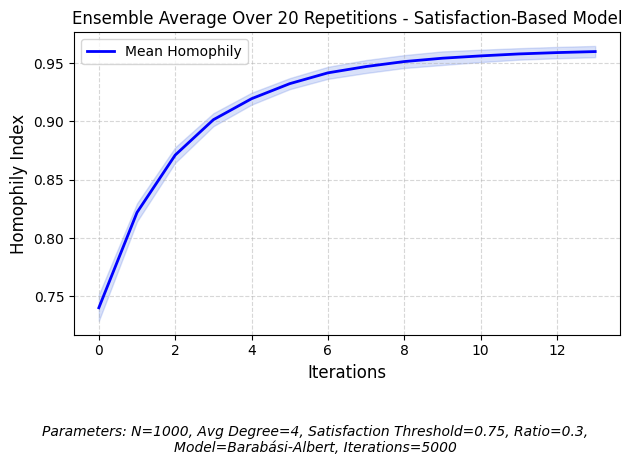

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.95, Ratio=0.3, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5815
Initial unsatisfied nodes: 776
Full segregation achieved at step 14 (all nodes satisfied).
Final Homophily Index: 1.0000


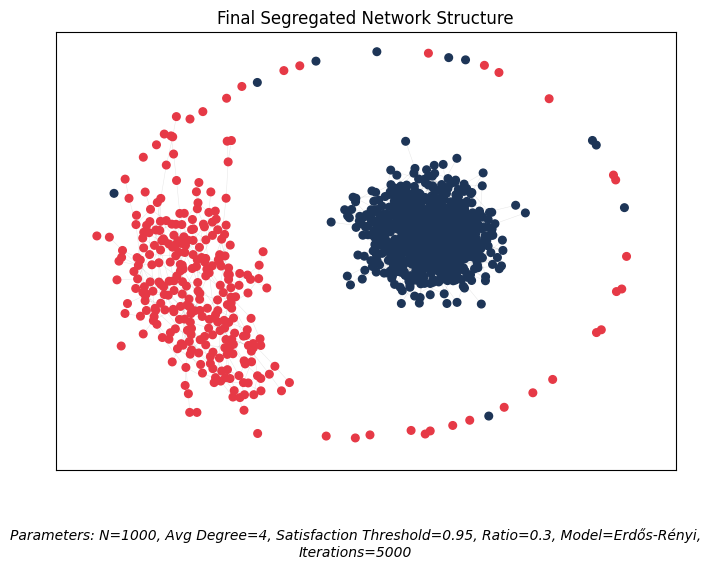

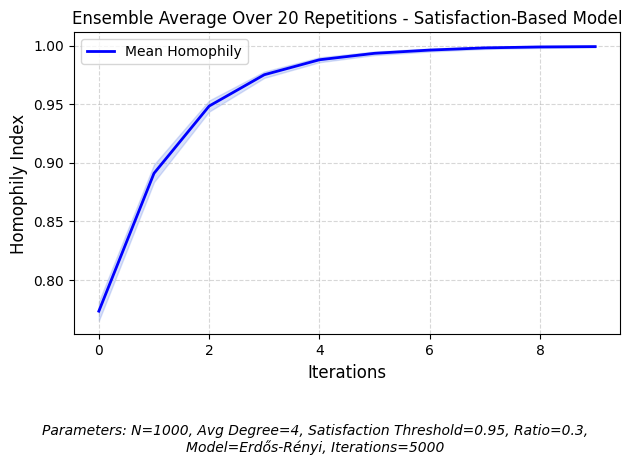

Running Parameters: N=1000, Avg Degree=4, Satisfaction Threshold=0.95, Ratio=0.3, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5762
Initial unsatisfied nodes: 732
Full segregation achieved at step 18 (all nodes satisfied).
Final Homophily Index: 1.0000


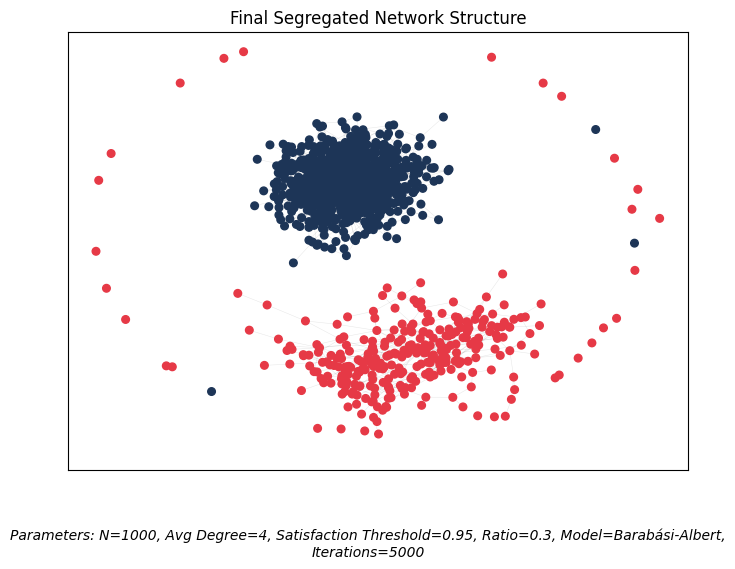

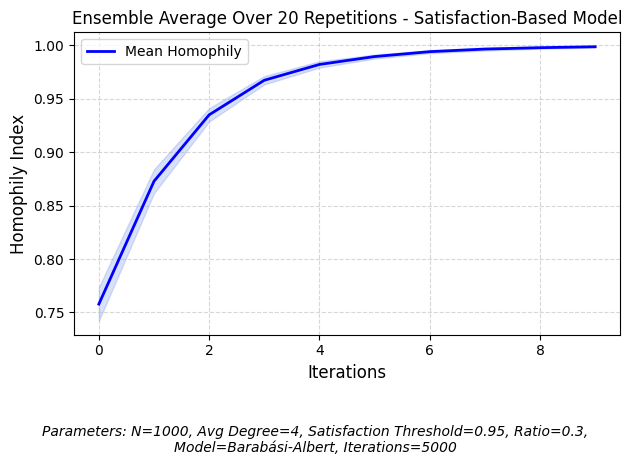

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.5, Ratio=0.3, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5806
Initial unsatisfied nodes: 312
Full segregation achieved at step 32 (all nodes satisfied).
Final Homophily Index: 0.7040


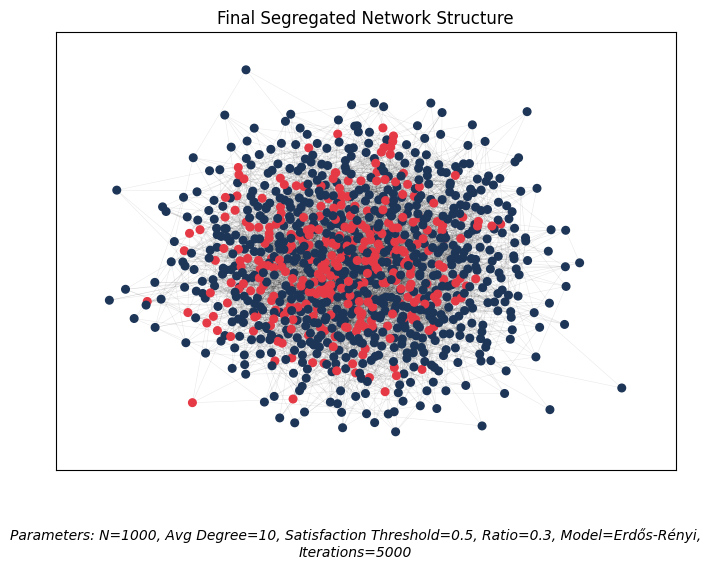

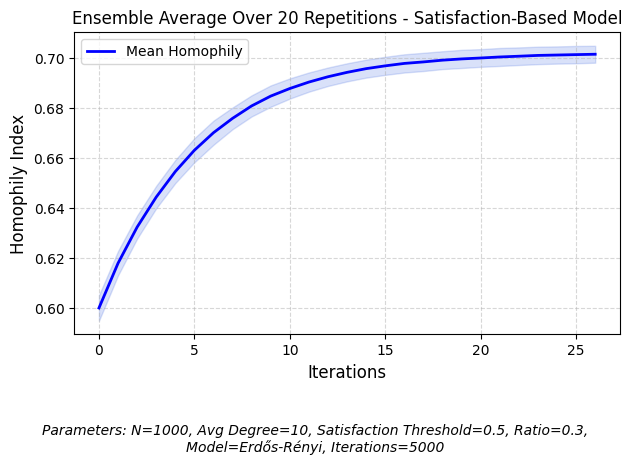

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.5, Ratio=0.3, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5829
Initial unsatisfied nodes: 322
Full segregation achieved at step 84 (all nodes satisfied).
Final Homophily Index: 0.7144


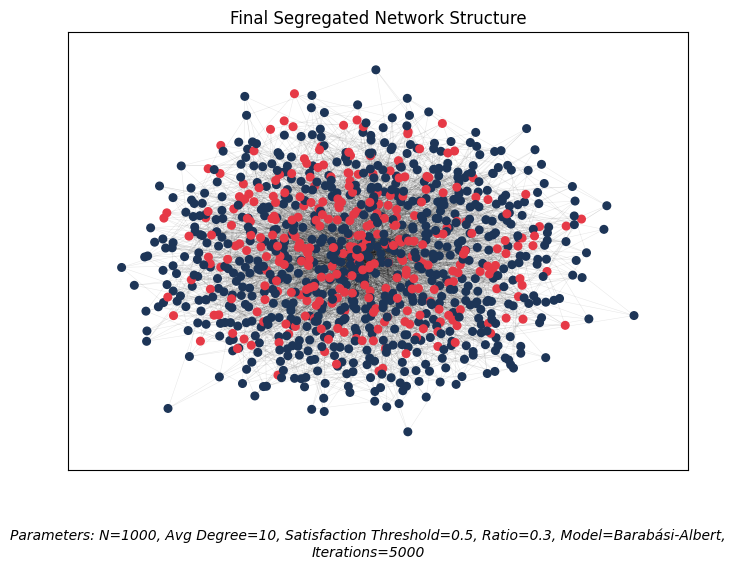

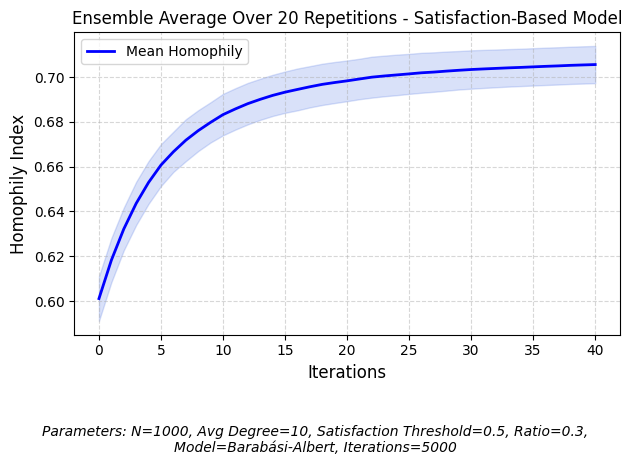

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.75, Ratio=0.3, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5892
Initial unsatisfied nodes: 676
Full segregation achieved at step 35 (all nodes satisfied).
Final Homophily Index: 0.8937


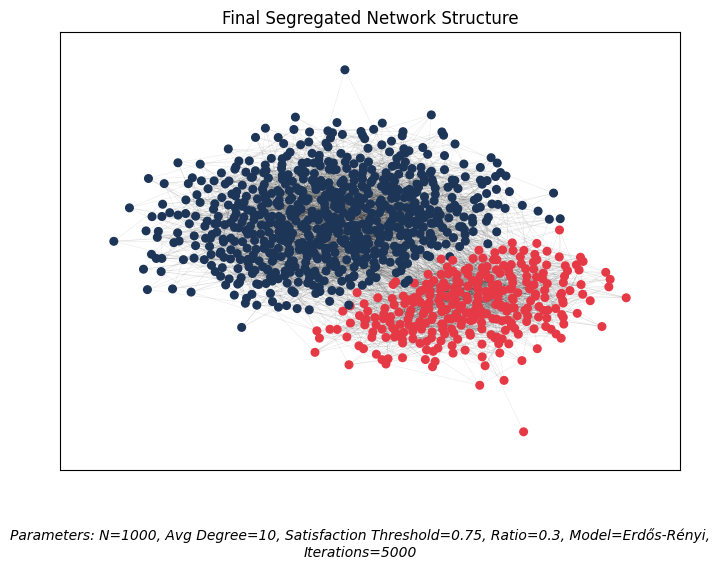

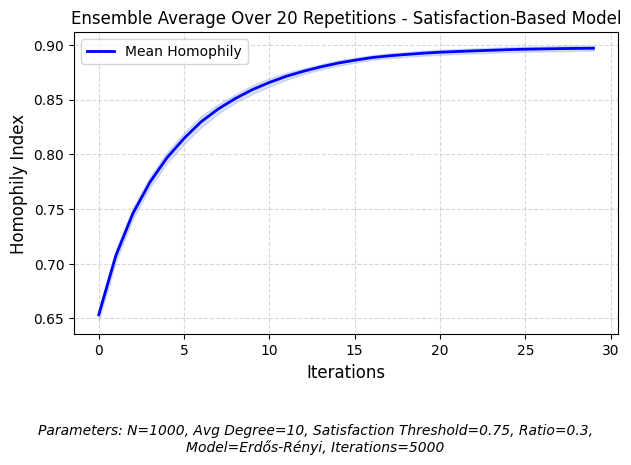

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.75, Ratio=0.3, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5853
Initial unsatisfied nodes: 711
Full segregation achieved at step 72 (all nodes satisfied).
Final Homophily Index: 0.9043


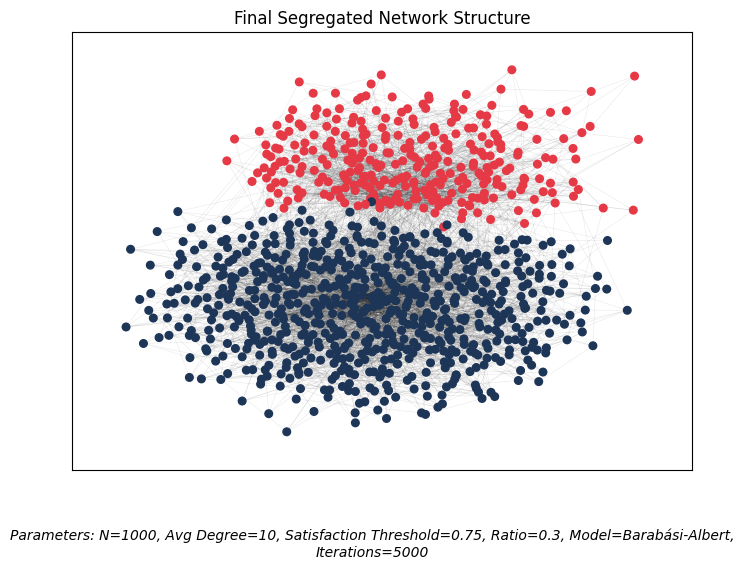

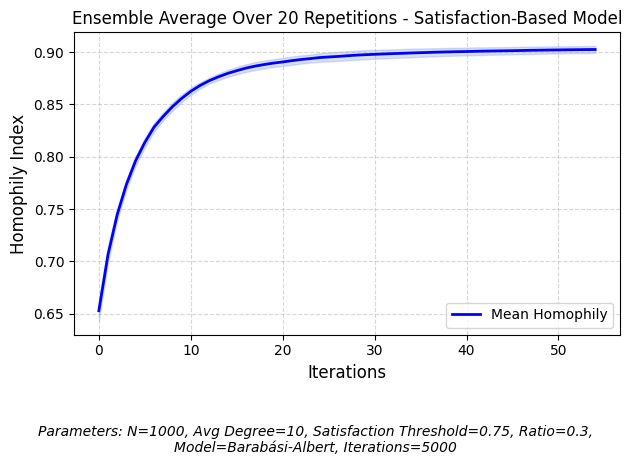

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.95, Ratio=0.3, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5800
Initial unsatisfied nodes: 970
Full segregation achieved at step 14 (all nodes satisfied).
Final Homophily Index: 1.0000


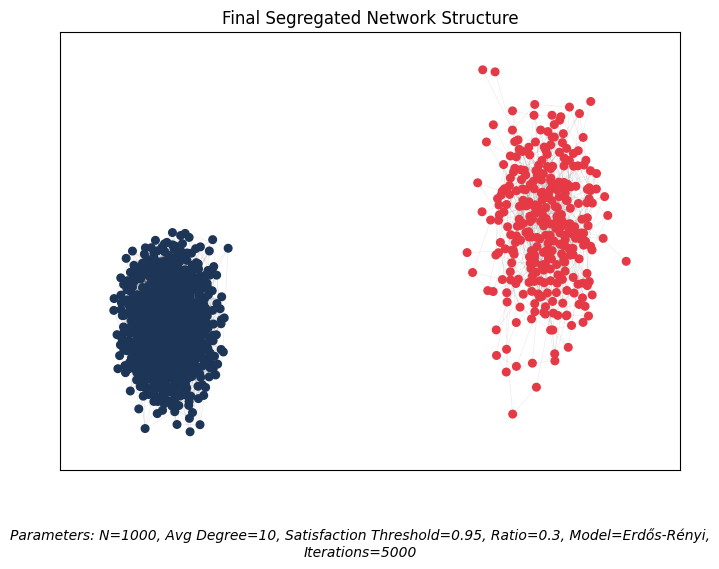

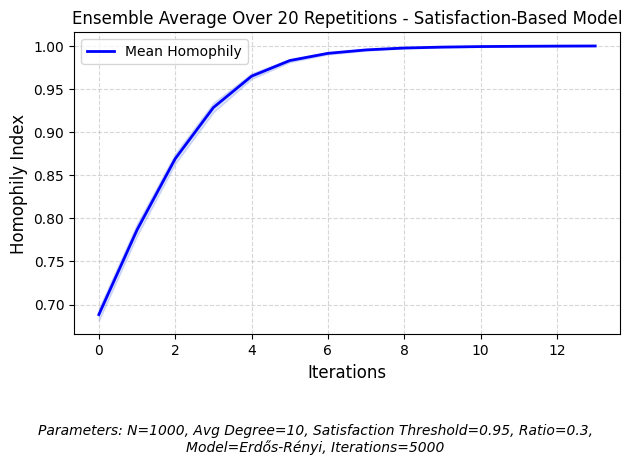

Running Parameters: N=1000, Avg Degree=10, Satisfaction Threshold=0.95, Ratio=0.3, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.6008
Initial unsatisfied nodes: 916
Full segregation achieved at step 15 (all nodes satisfied).
Final Homophily Index: 0.9998


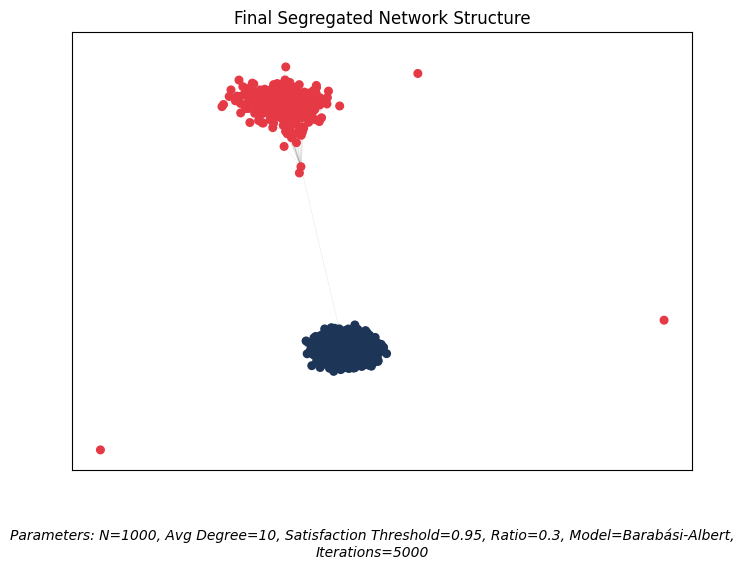

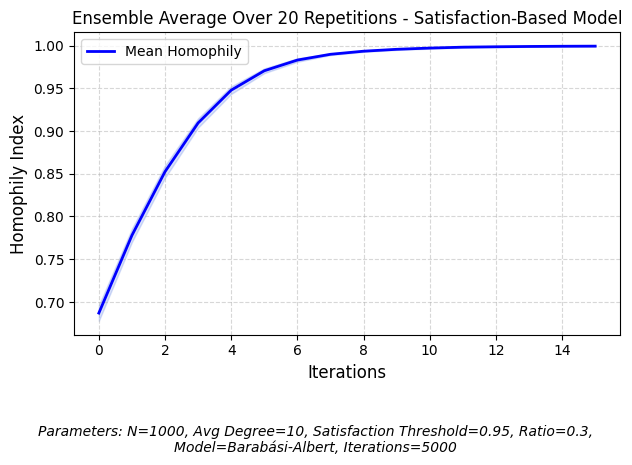

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.5, Ratio=0.3, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5770
Initial unsatisfied nodes: 302
Full segregation achieved at step 70 (all nodes satisfied).
Final Homophily Index: 0.6688


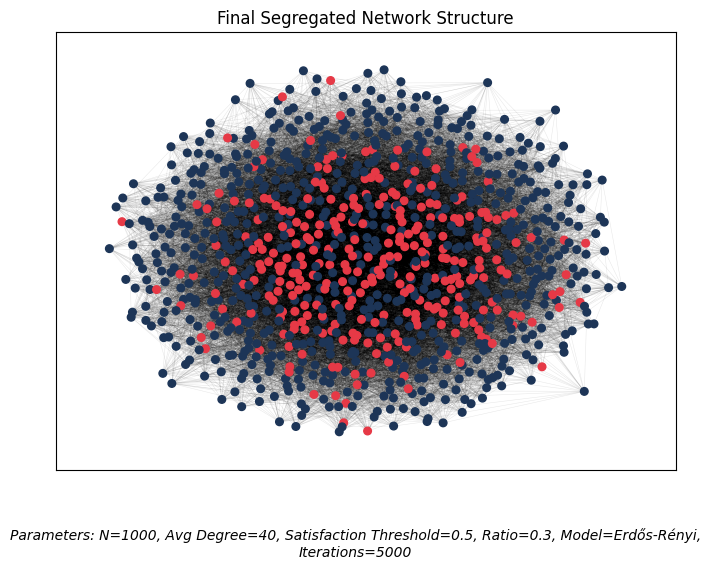

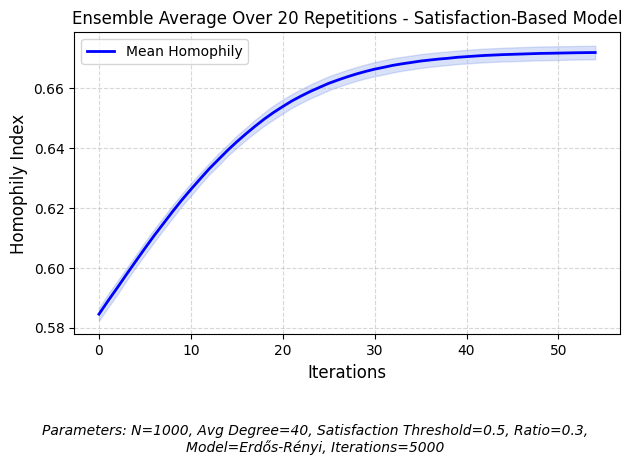

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.5, Ratio=0.3, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5660
Initial unsatisfied nodes: 303
Full segregation achieved at step 148 (all nodes satisfied).
Final Homophily Index: 0.6641


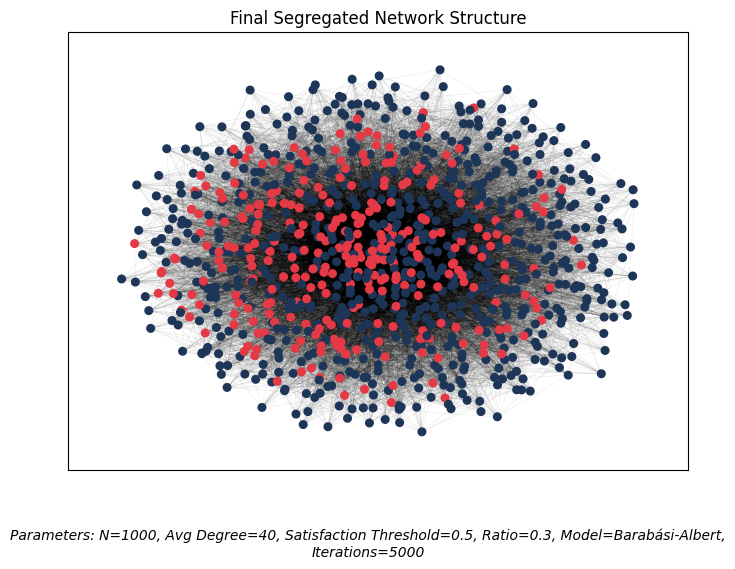

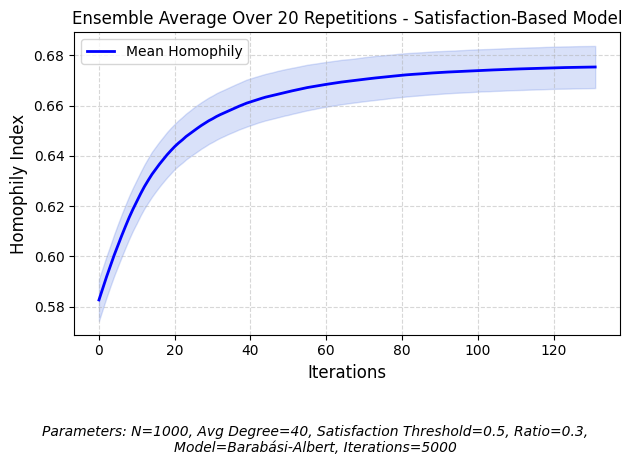

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.75, Ratio=0.3, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5770
Initial unsatisfied nodes: 823
Full segregation achieved at step 84 (all nodes satisfied).
Final Homophily Index: 0.8447


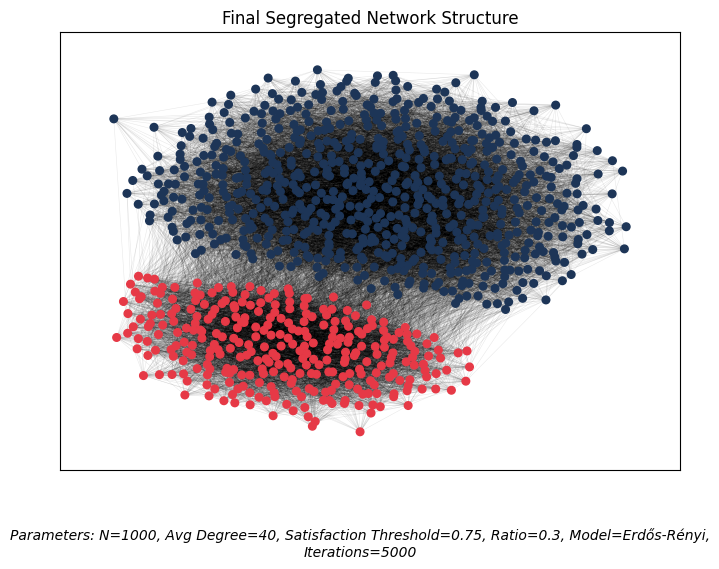

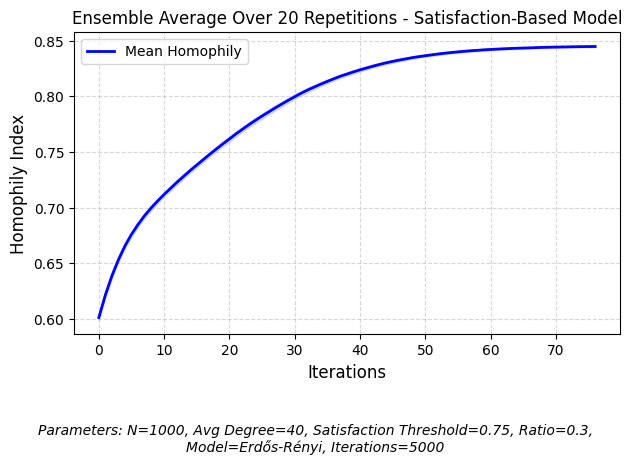

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.75, Ratio=0.3, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5693
Initial unsatisfied nodes: 821
Full segregation achieved at step 259 (all nodes satisfied).
Final Homophily Index: 0.8577


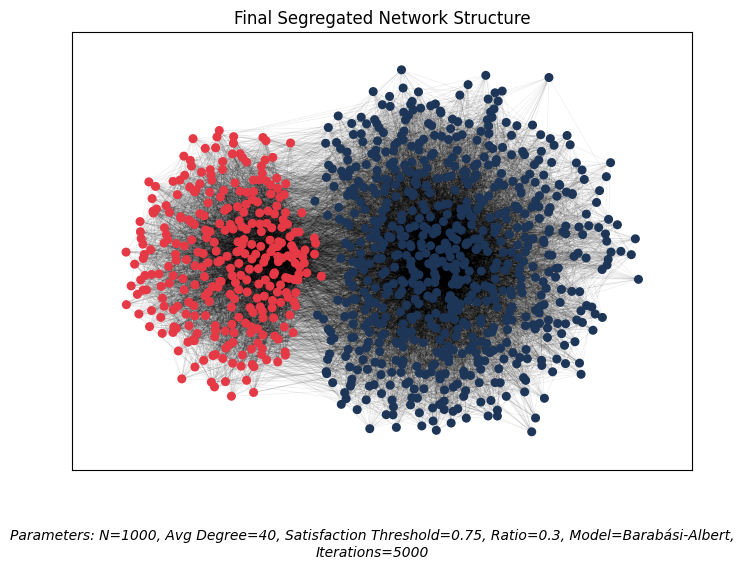

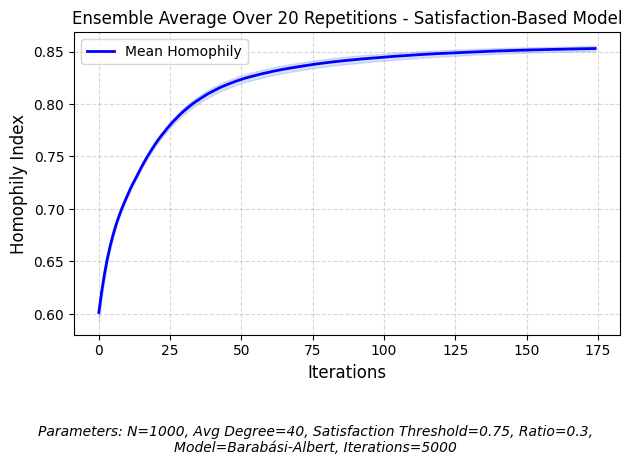

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.95, Ratio=0.3, Model=Erdős-Rényi, Iterations=5000...
Initial Homophily Index: 0.5748
Initial unsatisfied nodes: 1000
Full segregation achieved at step 51 (all nodes satisfied).
Final Homophily Index: 0.9898


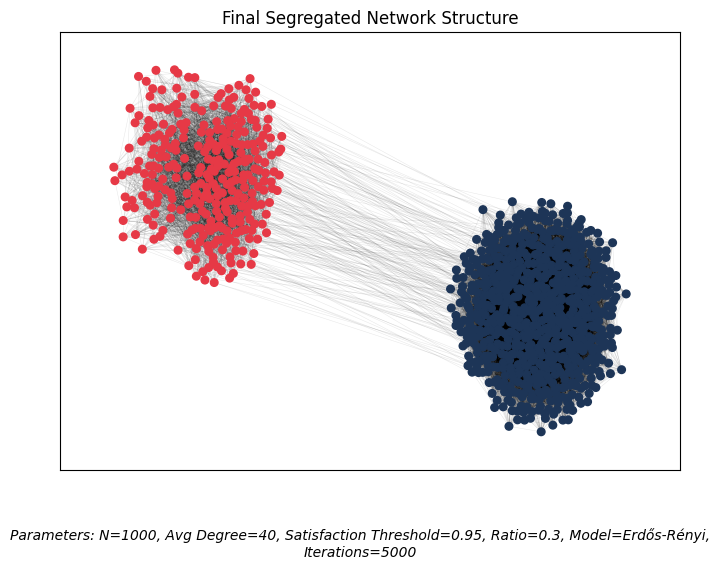

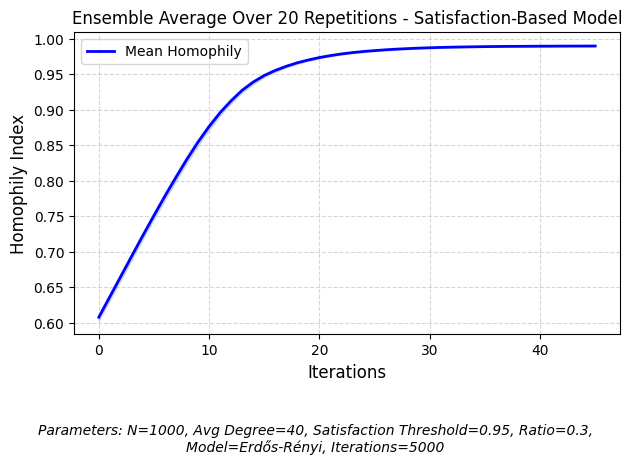

Running Parameters: N=1000, Avg Degree=40, Satisfaction Threshold=0.95, Ratio=0.3, Model=Barabási-Albert, Iterations=5000...
Initial Homophily Index: 0.5739
Initial unsatisfied nodes: 999
Full segregation achieved at step 97 (all nodes satisfied).
Final Homophily Index: 0.9917


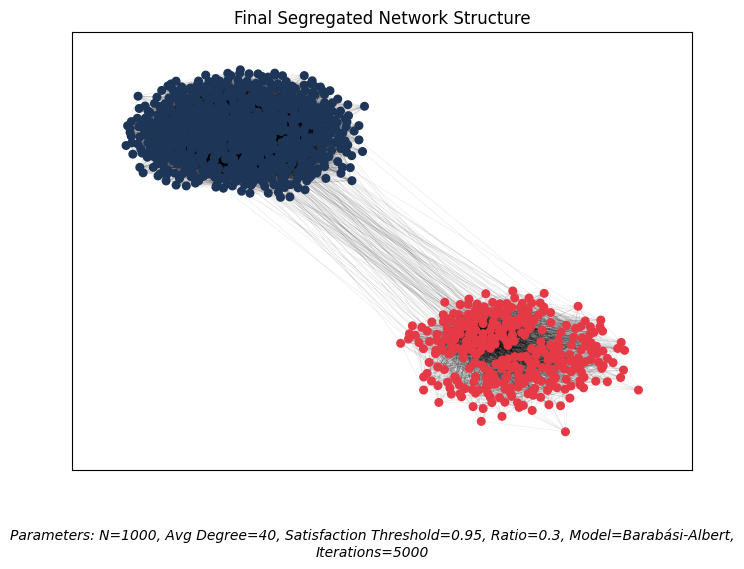

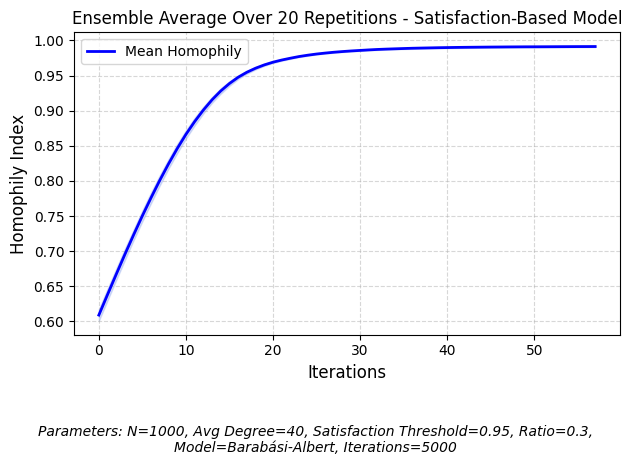

In [42]:
# Running the simulation loop
with open(f"{parent_logs}/summary.txt", "w") as f:
    f.write(f"Experiment Summary - N={N}, Iterations={ITERATIONS}\n")
    f.write("="*80 + "\n\n")

for ratio in RATIO:
    for avg_degree in AVG_DEGREE:
        for p_aversion in P_AVERSION:
            for er in ERDOS_RENYI:
                param_string = f"Parameters: N={N}, Avg Degree={avg_degree}, Satisfaction Threshold={p_aversion}, Ratio={ratio}, Model={'Erdős-Rényi' if er else 'Barabási-Albert'}, Iterations={ITERATIONS}"
                model_label = 'ER' if er else 'BA'
                exp_name = f"experiment_N{N}_avgdegree{avg_degree}_tau{p_aversion}_ratio{ratio}_{model_label}"
                exp_dir = os.path.join(parent_logs, exp_name)
                os.makedirs(exp_dir, exist_ok=True)
                evolution_dir = os.path.join(exp_dir, 'evolutionary_graph')
                os.makedirs(evolution_dir, exist_ok=True)

                G = initialize_network(N, avg_degree, ratio, er)
                print(f"Running {param_string}...")
                print(f"Initial Homophily Index: {get_homophily(G):.4f}")
                print(f"Initial unsatisfied nodes: {len(get_unsatisfied_nodes(G, p_aversion))}")
                history = []
                step = -1
                for i in range(ITERATIONS):
                    active = simulate_step(G, p_aversion)
                    history.append(get_homophily(G))
                    if i % 50 == 0:
                        
                        if EVOLUTION_PLOTS:
                            fig, ax = plt.subplots(figsize=(8, 8))

                            pos = nx.spring_layout(G, k=0.22, iterations=200, seed=42)
                            colors = ['#E63946' if G.nodes[n]['type'] == 0 else '#1D3557' for n in G.nodes()]
                            nx.draw_networkx_nodes(G, pos, node_size=18, node_color=colors, linewidths=0.2, edgecolors='black', alpha=0.9, ax=ax)
                            nx.draw_networkx_edges(G, pos, alpha=0.08, width=0.4, edge_color='gray', ax=ax)
                            unsatisfied_count = len(get_unsatisfied_nodes(G, p_aversion))
                            ax.set_title(f"Segregated Network Structure - Step {i} - Homophily: {history[-1]:.4f} - Unsatisfied: {unsatisfied_count}")
                            ax.set_axis_off()
                            plt.figtext(0.5, 0.01, param_string, wrap=True, horizontalalignment='center', fontsize=10, style='italic')

                            plt.tight_layout()
                            plt.subplots_adjust(bottom=0.15)
                            plt.savefig(f'{evolution_dir}/step_{i}.png')
                            plt.show()


                    if not active:
                        step=i
                        break
                
                history.append(get_homophily(G))
                if step == -1:
                    print("Reached maximum iterations without full segregation.")
                else:
                    print(f"Full segregation achieved at step {step} (all nodes satisfied).")
                    print(f"Final Homophily Index: {history[-1]:.4f}")
                
                plot_final_results(G, history, param_string, exp_dir, step, exp_name, avg_degree, ratio, p_aversion, model_label, N)
                initial_homophily_mean, initial_unsatisfied_mean, full_segregation_steps_mean, final_homophily_mean = plot_ensemble_results(param_string, exp_dir, exp_name, avg_degree, ratio, p_aversion, er, N)
                with open(f"{parent_logs}/summary.txt", "a") as f:
                    f.write(f"{param_string}\n")
                    f.write(f"Initial Homophily Index (mean over ensemble): {initial_homophily_mean:.4f}\n")
                    f.write(f"Initial Unsatisfied Nodes (mean over ensemble): {initial_unsatisfied_mean:.2f}\n")
                    f.write(f"Full Segregation Steps (mean over ensemble): {full_segregation_steps_mean:.2f}\n")
                    f.write(f"Final Homophily Index (mean over ensemble): {final_homophily_mean:.4f}\n")
                    f.write("\n")